# **Telcom Customer Churn Data Analysis**

In [37]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.feature_selection import SelectKBest, chi2

import joblib

In [38]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [39]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [40]:
df.shape
df.columns
df.info(all)
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


#Replacing blanks with 0 as tenure is 0 & changing type.

In [41]:
df["TotalCharges"]=df["TotalCharges"].replace(" ",0)
df["TotalCharges"]=df["TotalCharges"].astype(float)

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


#inspecting null values in data

In [43]:
df.isnull().sum().sum()

np.int64(0)

In [44]:
df["customerID"].duplicated().sum()

np.int64(0)

In [45]:
def conv(value):
    if value == 1:
        return "Yes"
    else:
        return "No"
df['SeniorCitizen']=df['SeniorCitizen'].apply(conv)

#converted 0 & 1 values of seniorcitizen to yes/no to make it easier to comprehend. 

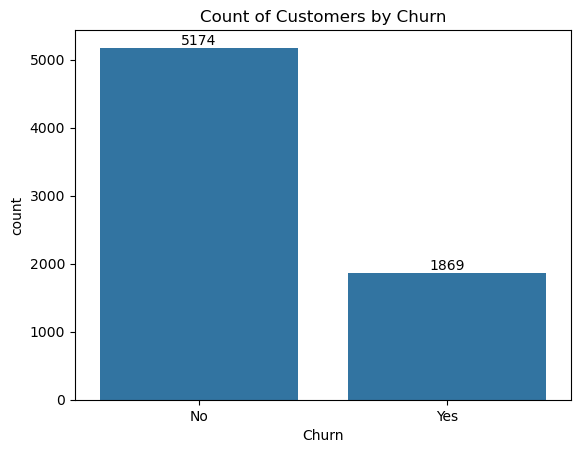

In [46]:
ax = sns.countplot(x="Churn",data=df)

ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Churn")
plt.show()

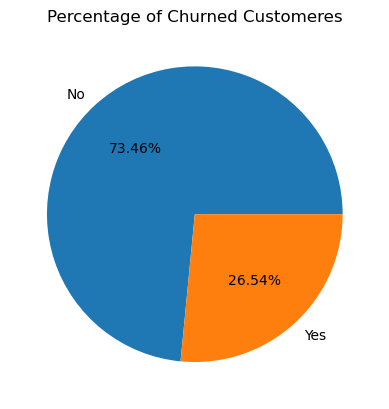

In [47]:
gb = df.groupby("Churn").agg({'Churn':"count"})                #using pie chart to see churn in percentage -> string is not getting converted to float so we do group by the data; aggregating ,have to find count of churn for yes & no
plt.pie(gb['Churn'],labels = gb.index, autopct = "%1.2f%%")    #want to show data as per gb.index in % in pie chart with label.
plt.title("Percentage of Churned Customeres", fontsize= 12)                                
plt.show()

#from pie chart, we conclude that 26.54% customers have churned out. Now let's explore the reason behind it:

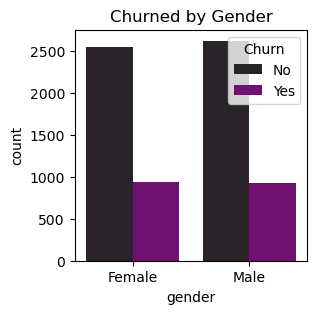

In [48]:
plt.figure(figsize=(3,3))
sns.countplot(x="gender", data=df, hue = "Churn", color='purple')
plt.title("Churned by Gender")
plt.show()

#Equal amount of male and female churning out so it is not gender specific.

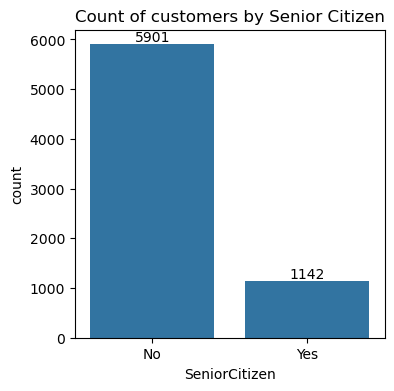

In [49]:
plt.figure(figsize=(4,4))
ax = sns.countplot(x="SeniorCitizen", data=df)
ax.bar_label(ax.containers[0])
plt.title("Count of customers by Senior Citizen")
plt.show()

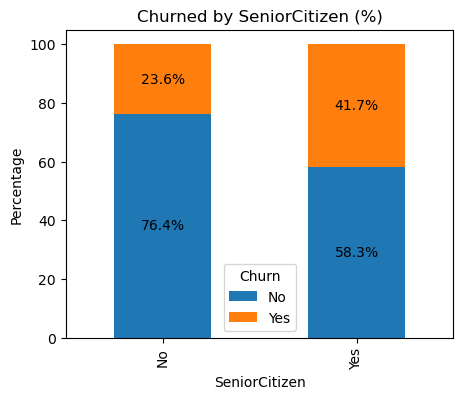

In [50]:
# Count churn by SeniorCitizen
ct = pd.crosstab(df["SeniorCitizen"], df["Churn"])

# Convert counts to percentage
ct = ct.div(ct.sum(axis=1), axis=0) * 100

# Plot stacked bar chart
ax = ct.plot(kind="bar", stacked=True, figsize=(5,4))

# Add % labels
for c in ax.containers:
    ax.bar_label(c, label_type="center", fmt="%.1f%%")

plt.title("Churned by SeniorCitizen (%)")
plt.xlabel("SeniorCitizen")
plt.ylabel("Percentage")
plt.legend(title="Churn")
plt.show()


#In stack bar chart,who are not senior citizen from that 23.6% people have churned out , who are senior citizen from that 41.7% people have churned out.

#comparative a greater percentage of people in senior citizen category have churned. 

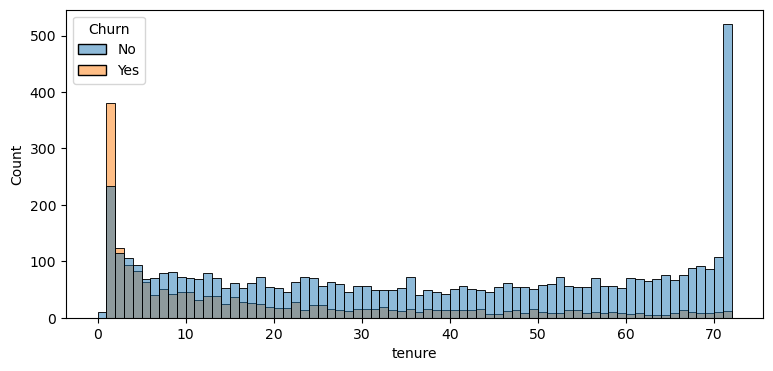

In [51]:
plt.figure(figsize=(9,4))
sns.histplot(x="tenure",data=df, bins=72, hue = "Churn")
plt.show()

#People who have used our services for a long time have stayed and people who have used our services for one to two months have churned.

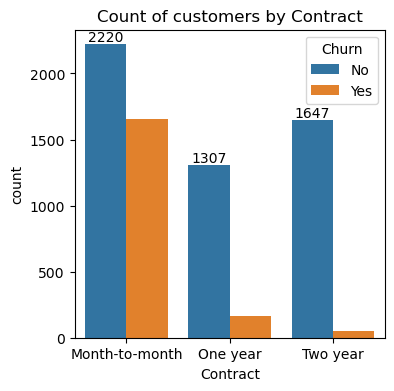

In [52]:
plt.figure(figsize=(4,4))
ax = sns.countplot(x="Contract", data=df, hue="Churn")
ax.bar_label(ax.containers[0])
plt.title("Count of customers by Contract")
plt.show()

#People who have month to month contract are likely to churn then from those who have 1 or 2 years of contract. 

In [53]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

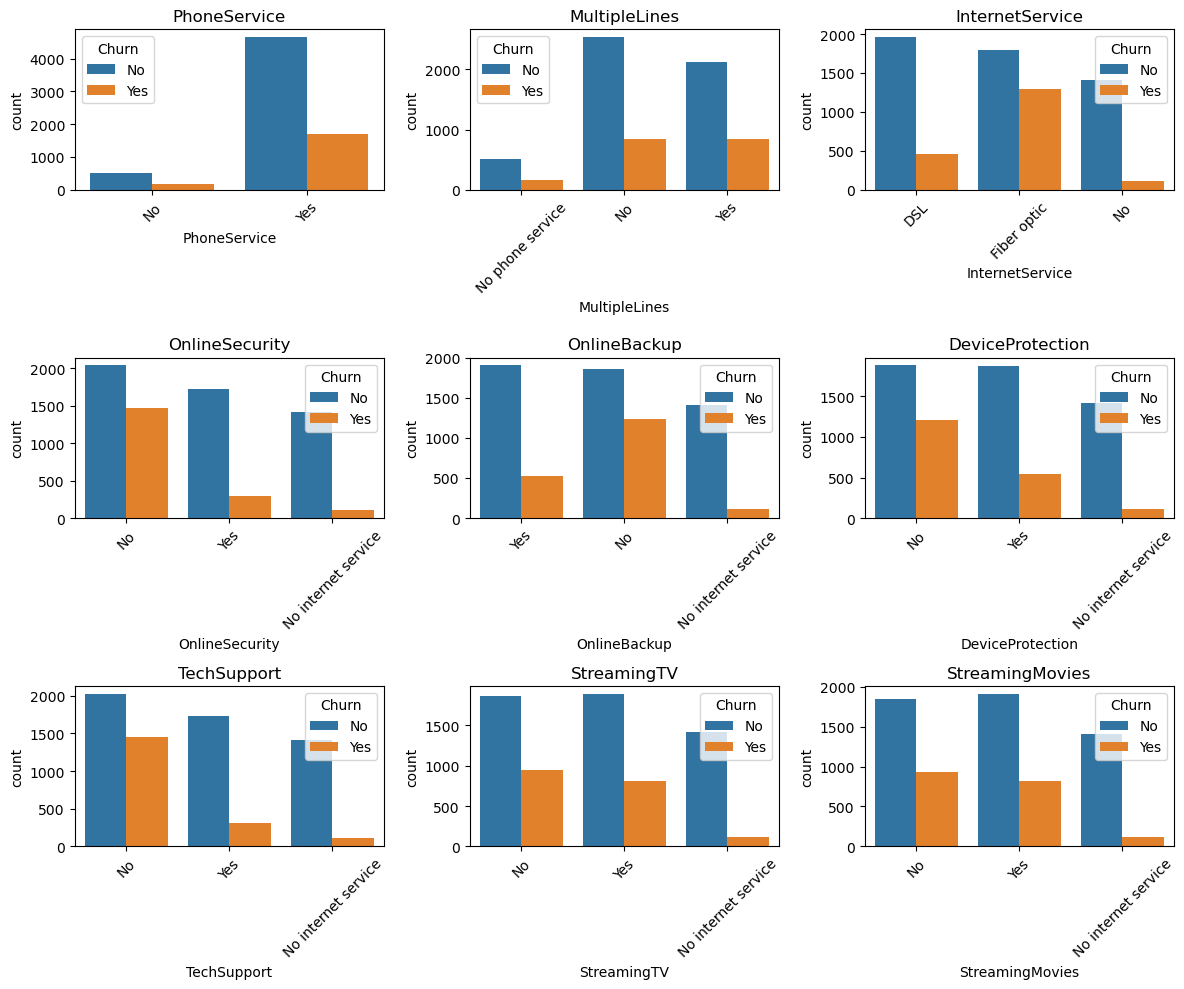

In [54]:
cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Create subplots (3 rows × 3 columns)
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()   # make axes easy to use

# Loop through columns and axes
for i, col in enumerate(cols):
    sns.countplot(x=col, data=df, ax=axes[i], hue=df["Churn"])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


#Customers using **fiber optic internet** show the **highest churn** compared to DSL or no internet service. Churn is significantly higher among customers who **do not have OnlineSecurity, TechSupport, or DeviceProtection**. Customers with **add-on services** like OnlineBackup and TechSupport are more likely to stay. Overall, lack of service support features is strongly associated with customer churn.


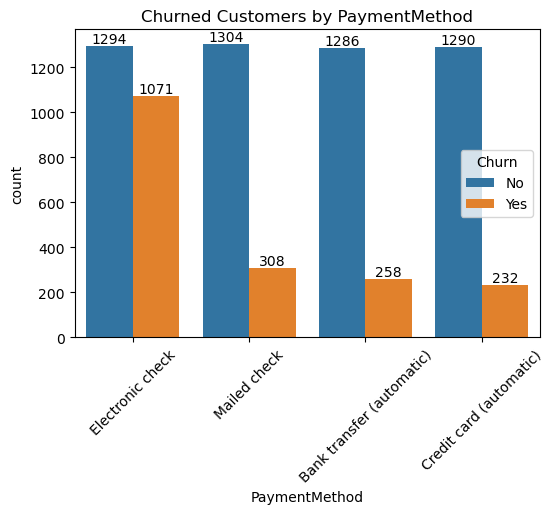

In [55]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x="PaymentMethod", data=df, hue="Churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churned Customers by PaymentMethod")
plt.xticks(rotation = 45)
plt.show()

#customer is likely to churn when he/she is using electronic check as a payment method. 

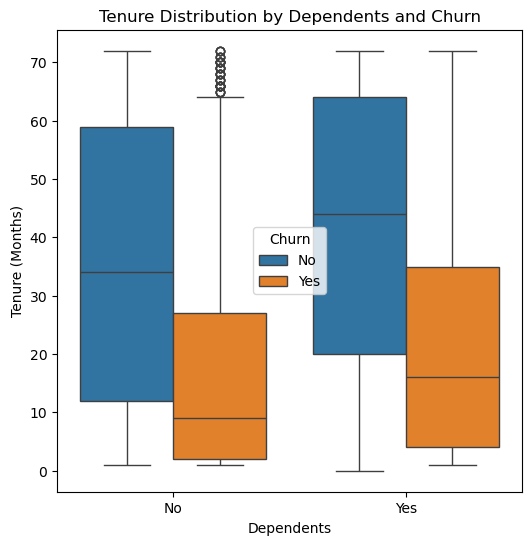

In [56]:
plt.figure(figsize=(6,6))
ax = sns.boxplot(
    x='Dependents',
    y='tenure',
    hue='Churn',
    data=df
)

plt.title("Tenure Distribution by Dependents and Churn")
plt.xlabel("Dependents")
plt.ylabel("Tenure (Months)")
plt.show()

#**Interpretation:**

* Customers **without dependents who churned** have a **median tenure of 9 months**, compared to **34 months** for those who did not churn.
* Customers **with dependents who churned** still stay longer, with a **median tenure of 16 months**, versus **44 months** for non-churners.
* Overall, having **dependents increases tenure by 10–15 months**, and **churn is strongly associated with low tenure**, especially for customers without dependents.

In [57]:
categorical_features=['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',  'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod','Churn']

In [58]:
numerical_features=['tenure', 'MonthlyCharges', 'TotalCharges']

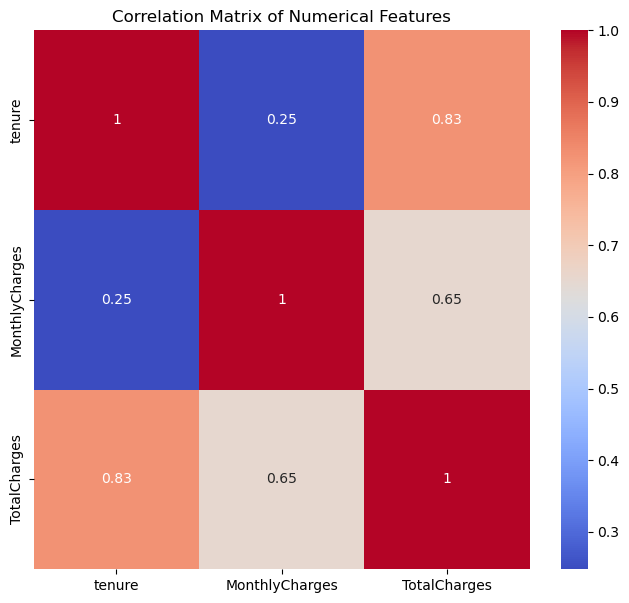

In [59]:
plt.figure(figsize=(8,7))
sns.heatmap(df[numerical_features].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

**Tenure and TotalCharges** show a **strong positive correlation (0.83)**, meaning customers who stay longer accumulate higher total charges.
* **MonthlyCharges and TotalCharges** have a **moderate positive correlation (0.65)**, indicating higher monthly bills generally lead to higher total spending.
* **Tenure and MonthlyCharges** show a **weak positive correlation (0.25)**, suggesting monthly charges do not increase much with customer tenure.

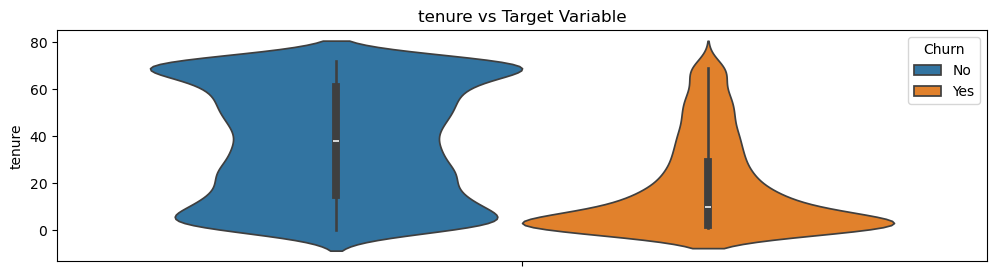

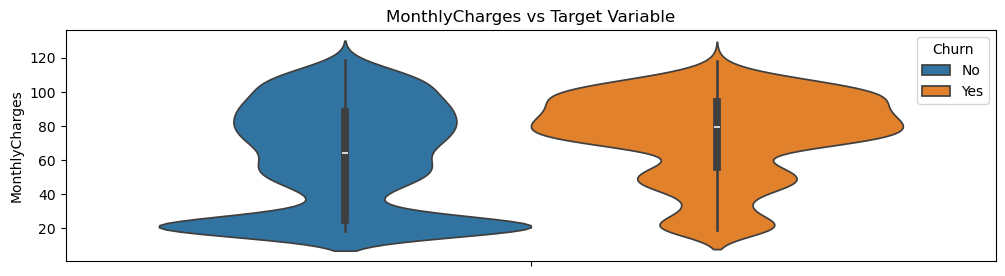

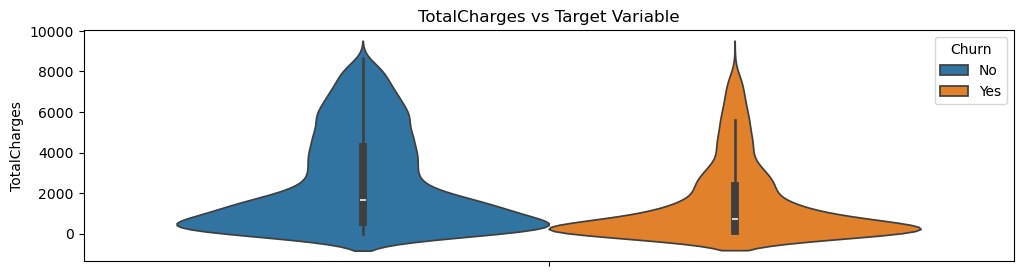

In [60]:
for features in numerical_features:
    plt.figure(figsize=(12,3))
    sns.violinplot(y=df[features], hue=df['Churn'])
    plt.title(f'{features} vs Target Variable')
    plt.show()

#Customers who **did not churn (Churn = 0)** generally have **much higher tenure**, with values concentrated around **30–70 months**, while churned customers mostly have **low tenure (0–20 months)**
* **MonthlyCharges** are **higher on average for churned customers (Churn = 1)**, indicating customers paying more per month are more likely to leave.
* **TotalCharges** are significantly **higher for non-churned customers**, reflecting long-term retention, whereas churned customers accumulate lower total charges due to shorter tenure.

***Data Preprocessing***

In [61]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})
df['Dependents'] = df['Dependents'].map({'Yes':1, 'No':0})

In [62]:
df.drop(['customerID'], axis=1, inplace=True)

**Train & Test**

In [63]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

categorical_features= X.select_dtypes(include=['object']).columns
numerical_features= X.select_dtypes(include=['int64']).columns

In [64]:
X.dtypes

gender               object
SeniorCitizen        object
Partner              object
Dependents            int64
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
dtype: object

In [65]:
X_train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
2142,Female,No,No,1,21,Yes,No,DSL,Yes,No,Yes,No,No,Yes,One year,No,Mailed check,64.85,1336.80
1623,Female,No,No,0,54,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Two year,Yes,Bank transfer (automatic),97.20,5129.45
6074,Male,No,Yes,0,1,No,No phone service,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,23.45,23.45
1362,Male,No,No,0,4,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.20,237.95
6754,Male,No,No,1,0,Yes,Yes,DSL,Yes,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,0.00


In [66]:
y_train

2142    0
1623    0
6074    1
1362    1
6754    0
       ..
3772    1
5191    0
5226    0
5390    1
860     0
Name: Churn, Length: 5634, dtype: int64

In [67]:
# Target column
y_train = df.loc[X_train.index, 'Churn']
y_test  = df.loc[X_test.index, 'Churn']

# Initialize encoder
le = LabelEncoder()

# Fit ONLY on training target
y_train_encoded = le.fit_transform(y_train)

# Transform test target
y_test_encoded = le.transform(y_test)


In [68]:
y_test_encoded[:5]                          #shows the first 5 encoded (numeric) target values of the test data.

array([1, 0, 0, 1, 0])

#Select the target (`Churn`) for train and test using indices, fit a LabelEncoder on the training target only, then transform both train and test targets into numeric labels (0/1).

In [69]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

#This setup **preprocesses** the data by handling **numerical features** and **categorical features** separately so they are ready to use.
Then a **Pipeline** sends this processed data to a **model (LogisticRegression)** to make predictions.

In [70]:
pipe.fit(X_train, y_train_encoded)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [77]:
y_pred = pipe.predict(X_test)

This image shows the **Pipeline flow**: data first goes through **preprocess (ColumnTransformer)** where **num → StandardScaler** and **cat → OneHotEncoder** are applied.
After preprocessing, the cleaned data is passed to **LogisticRegression**, and then **`pipe.predict(X_test)`** is used to generate predictions.

In [72]:
print("Accuracy:", accuracy_score(y_test_encoded, y_pred))
print(confusion_matrix(y_test_encoded, y_pred))
print(classification_report(y_test_encoded, y_pred))

Accuracy: 0.8211497515968772
[[939  97]
 [155 218]]
              precision    recall  f1-score   support

           0       0.86      0.91      0.88      1036
           1       0.69      0.58      0.63       373

    accuracy                           0.82      1409
   macro avg       0.78      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409



The model achieves a **good overall accuracy of about 82%**, meaning most predictions are correct. It performs **very well for class 0**, with high precision and recall, but **struggles with class 1**, missing many true cases. The confusion matrix shows that **class 1 is often predicted as class 0**, indicating imbalance in the data. Because class 0 has more samples, the overall accuracy looks strong, but **class 1 performance needs improvement**. Techniques like class weighting or model tuning could help improve results for class 1.

**tuning a machine-learning model (Logistic Regression) using GridSearchCV.**

In [79]:
from sklearn.model_selection import GridSearchCV   #GridSearchCV is like a smart helper that tries all possible combinations of your model settings, 
                                                   #checks which one works best on your training data (with cross-validation), 
                                                   #and gives you the most reliable model ready to predict new data.


param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear'],
    'model__class_weight': [None, 'balanced']
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,                                         #the data is split into 5 parts, and the model is trained and tested 5 times so the result is more reliable.
    scoring='f1',   # better than accuracy for imbalance
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_             #Save the best‑performing model (with the best settings) into best_model, so I can use it later.

In [81]:
y_pred = best_model.predict_proba(X_test)[:,1] > 0.4

#This line means the model **calculates the chance of a “yes/1” outcome**, and if that chance is **greater than 0.4**, it marks the result as **true (1)**; otherwise, it marks it as **false (0)**.

In [75]:
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.92      0.73      0.82      1036
           1       0.53      0.82      0.64       373

    accuracy                           0.76      1409
   macro avg       0.72      0.78      0.73      1409
weighted avg       0.82      0.76      0.77      1409



In [76]:
from sklearn.metrics import roc_auc_score

y_prob = best_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)
print(roc_auc)


0.8607813098429722


# Conclusion

- The model’s report shows it predicts class 0 very well, with high precision (0.92) but lower recall (0.73), meaning it misses some actual 0 cases.
- For class 1, recall is high (0.82), so the model catches most positive cases, but precision is low (0.53), meaning more false alarms.
- Overall accuracy is 76%, which is decent but not the best metric because the data is imbalanced.
- The ROC-AUC score of 0.86 indicates the model is good at separating class 0 and class 1.

Recall is high (good for catching churners), low precision drags F1 down → the model triggers many false alarms.
This model is good at finding most churners, but it also bothers many loyal customers thinking they might churn.”

Model catches most churners (good recall), but flags many loyal customers as churners (low precision).

F1 combines this into one number (0.64) → shows the model is okay but not perfect.

F1 tells if model is smart enough to find churners without bothering too many good customers.